# Phase 3 — steady↔unsteady 2D-slice correlation gate

**Dual-mode**: runs on **Colab** (CPU runtime — SU2 is single-threaded, GPU wastes quota) or **locally** (macOS SU2 binary via Rosetta). The notebook auto-detects which.

Thin orchestration only — all logic is tested library code in `fanopt.cfd.{mesh_2d_slice,configs,parsers,j_fan,correlation,phase3}` and `scripts/run_phase3_correlation.py` (CLAUDE.md §6). For each design we run the cheap **steady** slice (CD) and the true **2D-unsteady** plunging slice (cycle-averaged force) and correlate them. **R² ≥ 0.4** retains the steady tier as a screening fidelity (report-final.md §Phase 3).

## 1. Repo + Python/native deps

In [1]:
import importlib.util
import subprocess
import sys
from pathlib import Path

IN_COLAB = importlib.util.find_spec("google.colab") is not None

if IN_COLAB:
    REPO_DIR = Path("/content/fan-optimization")
    BRANCH = "main"
    REPO_URL = "https://github.com/clingergab/fan-optimization.git"
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", "-b", BRANCH, REPO_URL, str(REPO_DIR)], check=True)
    else:
        # Force-sync to the branch — avoid stale checkouts across sessions.
        subprocess.run(["git", "-C", str(REPO_DIR), "fetch", "origin", BRANCH], check=True)
        subprocess.run(["git", "-C", str(REPO_DIR), "checkout", BRANCH], check=True)
        subprocess.run(["git", "-C", str(REPO_DIR), "pull", "origin", BRANCH], check=True)
    # gmsh dlopens libGLU + X libs at import; Colab CPU runtimes lack them.
    subprocess.run(
        "apt-get install -qq -y libglu1-mesa libxrender1 libxcursor1 "
        "libxft2 libxinerama1 unzip".split(),
        check=True,
    )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "gmsh", "cadquery", "scipy", "jinja2"],
        check=True,
    )
else:
    # Local: walk up to the repo root (the dir holding pyproject.toml).
    REPO_DIR = Path.cwd()
    while REPO_DIR != REPO_DIR.parent and not (REPO_DIR / "pyproject.toml").exists():
        REPO_DIR = REPO_DIR.parent

for p in (REPO_DIR / "src", REPO_DIR / "scripts"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

assert (REPO_DIR / "scripts" / "run_phase3_correlation.py").exists(), \
    "phase-3 code missing — is the branch pushed?"
print("repo:", REPO_DIR, "| colab:", IN_COLAB)

repo: /Users/gclinger/Projects/fan-optimization | colab: False


## 2. SU2 — install (Colab) or locate (local)

In [2]:
import importlib.util
import os
import subprocess
import urllib.request
from pathlib import Path

if importlib.util.find_spec("google.colab") is not None:
    SU2_VERSION = "8.0.1"
    SU2_DIR = Path("/content/su2")
    if not any(SU2_DIR.rglob("SU2_CFD")):
        url = (
            f"https://github.com/su2code/SU2/releases/download/"
            f"v{SU2_VERSION}/SU2-v{SU2_VERSION}-linux64.zip"
        )
        print("[su2] downloading", url)
        urllib.request.urlretrieve(url, "/tmp/su2.zip")
        SU2_DIR.mkdir(parents=True, exist_ok=True)
        subprocess.run(["unzip", "-q", "-o", "/tmp/su2.zip", "-d", str(SU2_DIR)], check=True)
    # Pick the real binary (skip symlinks) and make the bin dir executable.
    cands = [p for p in SU2_DIR.rglob("SU2_CFD") if p.is_file() and not p.is_symlink()]
    assert cands, "SU2_CFD not found after extract — see colab_spike_0_6c.ipynb"
    bindir = cands[0].parent
    for p in bindir.iterdir():
        if p.is_file():
            os.chmod(p, 0o755)
else:
    # Local (Apple Silicon): the macOS SU2 binary runs under Rosetta 2.
    bindir = Path.home() / "su2-local" / "extracted" / "bin"
    assert (bindir / "SU2_CFD").exists(), f"SU2_CFD not at {bindir}"

os.environ["SU2_RUN"] = str(bindir)
os.environ["PATH"] = str(bindir) + os.pathsep + os.environ.get("PATH", "")
print("SU2_RUN:", os.environ["SU2_RUN"])

SU2_RUN: /Users/gclinger/su2-local/extracted/bin


## 3. Run the correlation sweep

The notebook demo runs the **first 3 designs** (~10 min local) so it completes interactively. The full 6-design ranking + `PASS/FAIL` artifact is produced by `python scripts/run_phase3_correlation.py --out-dir data/phase3_sweep`.

In [3]:
import run_phase3_correlation as script
from fanopt.cfd.phase3 import sweep_designs

WORK = REPO_DIR / "data" / "phase3_sweep_nb"
summary = script.run(out_dir=WORK, su2_bin=None, designs=sweep_designs()[:3])
print("R2 =", summary["r2"], "| tau =", summary["kendall_tau"], "| passed =", summary["passed"])
summary

R2 = 0.8918 | tau = 0.3333 | passed = True


{'metric': 'steady_cd_vs_unsteady_rms',
 'r2': 0.8918,
 'pearson_r': 0.9444,
 'kendall_tau': 0.3333,
 'n_designs': 3,
 'threshold': 0.4,
 'passed': True,
 'designs': [{'name': 'b3_t22',
   'steady_cd': 1.072200875,
   'unsteady_mean': -190892109112.5,
   'unsteady_rms': 40356220346973.125,
   'meta': {'n_blades': 3.0}},
  {'name': 'b3_t38',
   'steady_cd': 0.9127316937,
   'unsteady_mean': 2233972993137.5,
   'unsteady_rms': 46099031719156.77,
   'meta': {'n_blades': 3.0}},
  {'name': 'b4_t30',
   'steady_cd': 1.711512226,
   'unsteady_mean': -651572008574.625,
   'unsteady_rms': 77188803906981.48,
   'meta': {'n_blades': 4.0}}]}

## 4. Inspect — steady proxy vs unsteady RMS loading

We correlate steady `CD` against the unsteady **RMS loading amplitude**, not the cycle-mean. The mean net momentum flux (J_fan) is ~0 for these *symmetric* baseline panels (stroke forces cancel); the RMS amplitude is nonzero, converges in ~1 cycle, and is what steady CD can actually predict. J_fan (mean) stays the final ASO objective — the optimizer's job is to find asymmetric shapes that rectify it nonzero.

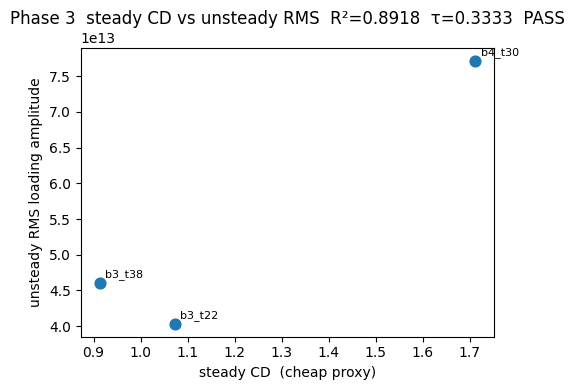

In [4]:
import json
import matplotlib.pyplot as plt

data = json.loads((WORK / "correlation.json").read_text())
xs = [d["steady_cd"] for d in data["designs"]]
ys = [d["unsteady_rms"] for d in data["designs"]]
names = [d["name"] for d in data["designs"]]

fig, ax = plt.subplots(figsize=(5.2, 4.0))
ax.scatter(xs, ys, s=60)
for x, y, n in zip(xs, ys, names):
    ax.annotate(n, (x, y), fontsize=8, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel("steady CD  (cheap proxy)")
ax.set_ylabel("unsteady RMS loading amplitude")
verdict = 'PASS' if data['passed'] else 'FAIL'
ax.set_title(f"Phase 3  steady CD vs unsteady RMS  R²={data['r2']}  τ={data['kendall_tau']}  {verdict}")
fig.tight_layout()
plt.show()